# 내 프로젝트 v1

# 실습 16 - 문제 정의서

## 문제 정의

**한 문장** : [반도체 공정 파라미터의 측정값으로, 공정이 끝나기 전 확보한 계측값을 통해 수율을 예측한다]

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | [공정 엔지니어] |
| 무엇을 결정하나 | [공정 파라미터(etch_rate, pressure, temperature, exposure_time, focus_offset, dose, deposition_rate, thickness_uniformity, implant_energy, tilt_angle)로 이 로트의 yield 값을 미리 예측한다] |
| 언제 결정하나 | [공정이 진행 중이라 계측값(critical_dimension 등)이 아직 없는 시점] |
| 이 판단이 늦으면 | [불량이 다음 공정까지 넘어가고, 고객사에서 발견되면 비용이 훨씬 커진다] |

In [1]:
import pandas as pd

df = pd.read_csv("../../data/semiconductor_yield_forecasting_data.csv")

print("전체 행 수:", len(df))
print("전체 열 개수:", len(df.columns))

숫자형_열 = df.select_dtypes(include="number").columns
print("숫자형 열 개수:", len(숫자형_열))

print(df["yield"].value_counts())
print(df["yield"].value_counts(normalize=True).round(4))

전체 행 수: 1250
전체 열 개수: 28
숫자형 열 개수: 19
yield
0.678783    1
0.779966    1
0.778492    1
0.405275    1
0.935350    1
           ..
0.434268    1
0.566107    1
0.442415    1
0.782406    1
0.666890    1
Name: count, Length: 1250, dtype: int64
yield
0.678783    0.0008
0.779966    0.0008
0.778492    0.0008
0.405275    0.0008
0.935350    0.0008
             ...  
0.434268    0.0008
0.566107    0.0008
0.442415    0.0008
0.782406    0.0008
0.666890    0.0008
Name: proportion, Length: 1250, dtype: float64


## 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | [공개 데이터(Kaggle)] |
| 규모 | [1250행 x 28열] |
| 입력으로 쓸 열 | [숫자로 된 측정 열 19개] |
| 결과 열 | [yield] |
| 결과 열의 값 | [숫자] |
| 기준선이 될 숫자 | [평균(0.4567)으로 항상 예측 시 MAE 0.143 / RMSE 0.175] |

## 한계

- [기록된 기간이 로트당 1일로 짧아 계절 변화, 원료 교체, 설비 노후와 같은 긴 흐름은 담기지 않았다]
- [critical_dimension, vth 등이 yield와 상관관계가 높게 나오더라도, 이 데이터만으로는 그것이 원인이라고 말할 수 없다. 조건을 실험적으로 통제한 것이 아니라 관찰된 값들이라, 상관관계와 인과관계를 구분할 근거가 없다.]
- [결측치가 없고, 로트-날짜-제품-설비가 정확히 1:1로 대응되는 등 구조가 지나치게 규칙적이다. 실제 양산 라인 데이터라면 흔한 결측·이상치·기록 누락이 전혀 없어서, 공개(Kaggle) 데이터 특성상 시뮬레이션/합성 데이터일 가능성을 고려해야 하고, 실제 현장 데이터와는 노이즈 양상이 다를 수 있다.]
- [로트당 조건이 1개로 고정돼 있어, 사실상 독립 표본은 1250개가 아니라 50개(로트 수)다. lot_id는 50개뿐이고, 로트마다 etch_tool·litho_tool·deposition_tool·implant_tool·product_type·technology_node가 각각 정확히 1개 값으로 고정돼 있다(로트당 웨이퍼 25개, etch_tool 고유값 수 = 1인 로트가 50/50). 즉 25개 웨이퍼는 같은 공정 조건에서 나온 반복 측정]

저장소에 올린 날 : [2026-08-24]

---
## 문제 정의 (후보 1 채택 — 웨이퍼별 yield 예측)

**한 문장** : 로트의 공정 설비 파라미터(에칭·노광·증착·임플란트 조건)만으로, 후공정 계측·전기 테스트 값이 나오기 전 시점에 그 웨이퍼의 yield를 예측한다.

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 공정 엔지니어 — etch_tool, litho_tool, deposition_tool, implant_tool 단위로 설비를 관리하는 담당자 |
| 무엇을 결정하나 | etch_rate, pressure, temperature, exposure_time, focus_offset, dose, deposition_rate, thickness_uniformity, implant_energy, tilt_angle 값으로 yield를 예측해, 이 로트를 그대로 다음 공정으로 넘길지 공정 조건을 재점검할지를 결정한다 |
| 언제 결정하나 | critical_dimension, oxide_thickness, resistivity, defect_count, defect_density, vth, leakage_current, resistance는 각 공정 단계 이후나 최종 전기 테스트(EDS)에서 나오는 계측값이라, 이 값들이 확정되기 전 — 즉 etch_tool~implant_tool 공정이 끝난 직후 시점에 예측해 쓴다. 다만 데이터에는 로트 단위 process_date만 있고 열별 계측 시점은 기록돼 있지 않아, 이 순서는 일반적인 반도체 공정 흐름(설비 조건 → 후공정 계측 → 전기 테스트 → yield 산출)에 따른 가정이다 |
| 이 판단이 늦으면 | critical_dimension~resistance 계측과 후속 공정까지 다 끝난 뒤에야 저수율이 드러나, 그 로트에 들어간 후속 공정 비용과 웨이퍼가 그대로 손실된다 |

**참고 (위 표 3행의 근거)** — 실제로 `fb8d4cab` 셀에서 구한 yield와의 상관관계를 보면, 상관관계 절댓값 상위 항목은 critical_dimension(-0.65), vth(-0.54), oxide_thickness(-0.51), resistance(-0.20), defect_count(-0.12), defect_density(-0.12)로 전부 후공정 계측/전기 테스트 값이다. 반면 "무엇을 결정하나"에 쓴 설비 파라미터 10개는 focus_offset(0.07), dose(0.06), thickness_uniformity(-0.12) 정도로 상관관계가 훨씬 약하다. 즉 이 문제는 "예측이 쉬운" 열들을 미리 빼고, 판단이 실제로 필요한 시점(설비 조건만 아는 시점)의 어려운 문제를 그대로 다루는 설정이다 — 그만큼 예측 정확도는 후공정 계측을 포함한 모델보다 낮을 것으로 예상해야 한다.


### 도전 - 말로 하는 30초 버전

웨이퍼가 최종 검사까지 가기 전, 에칭·노광·증착·임플란트 같은 앞단 설비 조건 값만으로 그 웨이퍼의 최종 수율, 즉 yield(정상적으로 만들어진 비율)를 미리 예측하는 문제입니다. 이걸 쓰는 사람은 그 설비들을 관리하는 공정 엔지니어이고, etch_rate·pressure·temperature 같은 설비 파라미터 10개로 예측한 yield를 보고 이 로트를 그대로 다음 공정에 넘길지, 조건을 재점검할지 판단합니다. critical_dimension이나 vth처럼 yield와 더 강하게 연관된 값들은 공정이 끝난 뒤 계측이나 최종 전기 테스트(EDS, 완성된 소자의 전기적 특성을 재는 검사)에서 나오기 때문에, 그 값들이 나오기 전 시점에 미리 알아야 의미가 있어서 일부러 이 시점을 골랐습니다. 그만큼 상관관계가 약한 값들만으로 푸는 어려운 문제라 정확도는 낮을 수 있다는 것도 감안하고 있고, 판단이 늦어지면 후공정 계측과 전기 테스트까지 다 끝난 뒤에야 저수율이 드러나 후속 공정 비용과 웨이퍼가 그대로 손실됩니다.

### 도전 - 말로 하는 30초 버전 (축약)

에칭·노광·증착·임플란트 같은 앞단 설비 조건만 보고, 웨이퍼의 최종 수율(yield, 정상 생산 비율)을 후공정 계측이 나오기 전에 미리 예측하는 문제입니다. 공정 엔지니어가 이 예측을 보고 로트를 그대로 다음 공정에 넘길지 재점검할지 판단하는데, critical_dimension이나 vth처럼 yield와 더 강하게 연관된 값이 나오기 전 시점이라 정확도는 낮을 수 있습니다. 판단이 늦으면 후속 공정 비용과 웨이퍼가 그대로 손실됩니다.

# 실습 17
## 모델링 계획
| # | 하는 일 | 내 경우엔 | 막힐 것 같나 |
|---|---|---|---|
| 1 | 파일 불러오기 | [../../data/semiconductor_yield_forecasting_data.csv] | |
| 2 | 빈칸 채우기 | [결측치 0건, 채울 빈칸 없음] | |
| 3 | 결과 열을 숫자로 | [해당 없음 — yield는 이미 숫자] | |
| 4 | 입력과 정답 나누기 | [입력은 설비 파라미터 10개, 정답은 yield] | |
| 5 | 학습용·시험용 나누기 | [로트 단위로 8대 2, GroupKFold로] | 막힐 것 같음 |
| 6 | 기준 모델 점수 재기 | [평균값 모델] | |
| 7 | 모델 하나 학습시키기 | [표준화한 뒤 선형회귀] | 막힐 것 같음 |
| 8 | 결과 읽기 | [기준 모델과 나란히 놓고 MAE·RMSE·R²로 비교] | 막힐 것 같음 |


### 이번 v1에서 볼 숫자

- 볼 지표 : [기준 모델(평균값 예측) MAE·RMSE / 학습한 모델의 MAE·RMSE·R²]
- 이걸 보는 이유 : [yield 값이 0.148~0.982 사이 좁은 범위에 몰려 있고 표준편차도 0.175밖에 안 돼서, 평균(0.4567)으로만 예측해도 MAE 0.143·RMSE 0.175로 숫자 자체는 꽤 작게 나온다. MAE·RMSE만 보면 모델이 잘 맞춘 것으로 착각하기 쉬우니, 기준 모델보다 실제로 나은지는 R²(0이면 평균 예측과 다를 게 없다는 뜻)로 반드시 같이 확인한다]

볼 지표 : [기준 모델(평균값) MAE·RMSE / 학습 모델의 MAE·RMSE·R²]
이걸 보는 이유 : [yield가 0.148~0.982로 범위가 좁고 표준편차도 0.175뿐이라 기준 모델의 MAE·RMSE도 이미 작게 나온다. 숫자만 보면 잘 맞춘 것처럼 보이니, 기준보다 실제로 나은지는 R²로 확인한다]

### 도전 - 입력에서 빼야 할 열이 있나 (데이터 누수 점검)

| 종류 | 있나 | 열 이름 | 어떻게 할까 |
|---|---|---|---|
| 번호·순번 열 | [있음] | [lot_id] [wafer_id] | [총 2개, 글자로 되어 있어 숫자 열에 안 잡힌다. 그대로 두면 자동으로 빠진다] |
| 판단 시점에 아직 없는 열 | [없음(yield는 목표값이라 입력 후보에서 이미 제외됨)] | [-] | [-] |
| 결과 열의 사본 | [없음] | [-] | [-] |

- 결론 : [입력 18개(숫자형)를 그대로 쓴다. 다만 R²가 비정상적으로 높게(예: 0.95 이상) 나오면 이 표를 다시 본다]

# 실습 18 - 모델링 v1

## 모델링 v1

### 문법 노트 - 코드에서 찾을 이름

| 이름 | 뜻 |
|---|---|
| features | 모델에 넣는 입력 열 목록 |
| label | 정답표 - 찾으려는 쪽이면 1, 아니면 0 |
| X / y | 입력 / 정답 |
| X_train, X_test | 학습용 입력 / 시험용 입력 |
| y_train, y_test | 학습용 정답 / 시험용 정답 |
| baseline | 기준 모델 - 학습 없이 전부 아니라고 답하는 것 |
| model | 학습시킨 모델 |
| y_pred | 모델이 내놓은 답 |
| precision / recall | 정밀도 / 재현율 |

## Step 3. 한 바퀴 돌리기

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

특징 = ["etch_rate", "pressure", "temperature", "exposure_time", "focus_offset",
       "dose", "deposition_rate", "thickness_uniformity", "implant_energy", "tilt_angle",
       "critical_dimension", "oxide_thickness", "resistivity", "defect_count",
       "defect_density", "vth", "leakage_current", "resistance"]
X = df[특징]
y = df["yield"]

# 로트 단위로 학습/시험을 나눈다 (같은 로트가 양쪽에 섞이지 않도록)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=df["lot_id"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# dose가 10^15 규모라 나머지 열과 스케일 차이가 극심함 - 표준화 없이는 선형회귀가 수치적으로 불안정해진다
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 기준 모델: 항상 학습용 평균값
기준_예측 = np.full(len(y_test), y_train.mean())

# 선형회귀 모델
model = LinearRegression()
model.fit(X_train_scaled, y_train)
내_예측 = model.predict(X_test_scaled)

결과 = pd.DataFrame({
    "기준 모델": [
        mean_absolute_error(y_test, 기준_예측),
        mean_squared_error(y_test, 기준_예측) ** 0.5,
        r2_score(y_test, 기준_예측),
    ],
    "내 모델": [
        mean_absolute_error(y_test, 내_예측),
        mean_squared_error(y_test, 내_예측) ** 0.5,
        r2_score(y_test, 내_예측),
    ],
}, index=["MAE", "RMSE", "R2(제곱)"])

결과

,기준 모델,내 모델
MAE,0.150779,0.108956
RMSE,0.194071,0.133209
R2(제곱),-0.201582,0.433893


## Step 4. 여러 번 나눠서 재보기

한 번의 분할(Step 3)에서 R²가 음수로 나왔는데, 이게 진짜 문제인지 분할 운인지 GroupKFold 5겹으로 반복해서 확인한다.

In [3]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
접기별_결과 = []

for i, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=df["lot_id"]), 1):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    # 여기서도 dose(10^15 규모) 때문에 표준화가 필요하다 - 겹마다 학습용 기준으로 새로 맞춘다
    scaler_i = StandardScaler()
    X_tr_scaled = scaler_i.fit_transform(X_tr)
    X_te_scaled = scaler_i.transform(X_te)

    기준_예측_i = np.full(len(y_te), y_tr.mean())
    모델_i = LinearRegression()
    모델_i.fit(X_tr_scaled, y_tr)
    예측_i = 모델_i.predict(X_te_scaled)

    접기별_결과.append({
        "겹": i,
        "기준 R2": r2_score(y_te, 기준_예측_i),
        "내 모델 R2": r2_score(y_te, 예측_i),
        "내 모델 MAE": mean_absolute_error(y_te, 예측_i),
        "내 모델 RMSE": mean_squared_error(y_te, 예측_i) ** 0.5,
    })

접기별_결과_표 = pd.DataFrame(접기별_결과).set_index("겹")
print(접기별_결과_표.round(4))
print()
print("내 모델 R2 평균:", 접기별_결과_표["내 모델 R2"].mean().round(4), " 표준편차:", 접기별_결과_표["내 모델 R2"].std().round(4))
print("기준 모델 R2 평균:", 접기별_결과_표["기준 R2"].mean().round(4), " 표준편차:", 접기별_결과_표["기준 R2"].std().round(4))

    기준 R2  내 모델 R2  내 모델 MAE  내 모델 RMSE
겹                                      
1 -0.3234   0.2797    0.1213     0.1486
2 -1.1535   0.1558    0.0877     0.1069
3 -0.0025   0.5033    0.0992     0.1273
4 -0.0742   0.4046    0.1027     0.1303
5 -0.0292   0.5609    0.0917     0.1145

내 모델 R2 평균: 0.3809  표준편차: 0.165
기준 모델 R2 평균: -0.3166  표준편차: 0.4849


### 참고) 왜 기준 모델의 R²가 0이 아니라 음수인가

R²가 정확히 0이 되려면, 예측에 쓴 평균이 **지금 평가하는 바로 그 데이터**의 평균이어야 한다. 그런데 기준 모델은 **학습용 평균**으로 **시험용**을 예측하기 때문에, 두 평균이 다르면 R²는 항상 0 이하로 나온다.

**공식**: `R²(기준모델) = −n × (시험평균 − 학습평균)² / 시험용 오차제곱합`

| 겹 | 학습평균 | 시험평균 | 차이 | 기준모델 R² |
|---|---|---|---|---|
| 1 | 0.4368 | 0.5363 | −0.0996 | −0.323 |
| 2 | 0.4817 | 0.3567 | **+0.1250(최대)** | **−1.154(최악)** |
| 3 | 0.4549 | 0.4638 | −0.0089(거의 0) | −0.003(거의 0) |
| 4 | 0.4475 | 0.4935 | −0.0460 | −0.074 |
| 5 | 0.4626 | 0.4330 | +0.0295 | −0.029 |

학습·시험 평균 차이가 클수록 기준모델 R²도 그만큼 나빠진다는 게 그대로 확인된다.

**원인**: 로트가 50개뿐이라, 특정 겹에 수율이 높은 로트(7nm·10nm 계열)나 낮은 로트(14~28nm 계열)가 몰리면 학습·시험 평균이 크게 벌어진다 — "로트 수가 적어 분할마다 결과가 흔들린다"는 한계가 기준 모델의 R²에도 그대로 나타난 것.

day07은 표본이 10,000행(시험용 2,000행)이라 학습·시험 평균 차이가 거의 0(0.0026, 표준편차의 0.18%)이라 기준모델 R²도 0에 가까웠다 — 운이 아니라 큰 수의 법칙 덕분.
day06은 독립 단위가 로트 50개뿐(시험용 10개)이라 평균 차이가 크게 벌어질 수 있어(겹2 기준 차이 0.125, 표준편차의 71%) 기준모델 R²도 −1.15까지 흔들린다.

## Step 5. 무엇을 보고 맞혔나

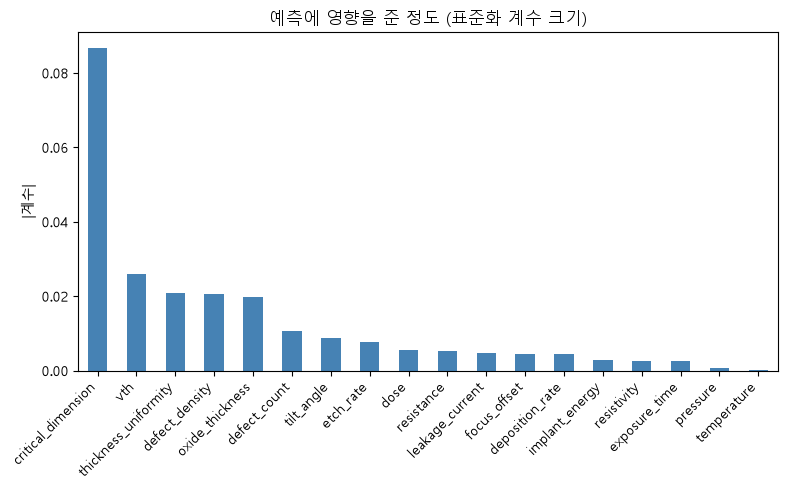

critical_dimension      0.086570
vth                     0.025821
thickness_uniformity    0.020932
defect_density          0.020583
oxide_thickness         0.019647
defect_count            0.010489
tilt_angle              0.008855
etch_rate               0.007558
dose                    0.005447
resistance              0.005376
leakage_current         0.004754
focus_offset            0.004504
deposition_rate         0.004360
implant_energy          0.002733
resistivity             0.002614
exposure_time           0.002581
pressure                0.000708
temperature             0.000102
dtype: float64

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# Step 3에서 표준화한 뒤 학습시킨 model을 그대로 쓴다 - 표준화했기 때문에 계수 크기끼리 비교가 가능하다
중요도 = pd.Series(model.coef_, index=특징).abs().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
중요도.plot(kind="bar", color="steelblue")
plt.title("예측에 영향을 준 정도 (표준화 계수 크기)")
plt.ylabel("|계수|")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

중요도

### 한계 추가 — 설비 파라미터와 계측값 사이에 물리적으로 기대되는 관계가 없음

- 반도체 물리상 강하게 연관돼야 할 쌍들의 상관계수를 직접 계산했더니 전부 0에 가까움: dose(도즈량) vs vth(문턱전압) −0.0074, exposure_time vs critical_dimension −0.0503, focus_offset vs critical_dimension −0.1729, etch_rate vs critical_dimension −0.0913
- 도즈량이 도핑 농도를 통해 문턱전압을 결정한다는 건 소자물리의 기본 관계인데, 이 데이터에는 그 관계가 사실상 없다
- 설비 파라미터로 분류한 thickness_uniformity와 계측값인 defect_density의 상관계수가 0.9996으로 거의 완벽히 겹침 — 서로 다른 범주로 분류된 두 열이 사실상 같은 값처럼 보여, 이 데이터의 열 분류 자체도 신뢰하기 어려움을 시사한다
- 실무에서는 설비 파라미터로 계측값을 미리 추정하는 가상계측(Virtual Metrology)·APC가 표준 관행으로 쓰이는데, 이 데이터는 그런 인과관계가 반영돼 있지 않다
- 앞서 적은 한계(결측치 0, 로트-날짜-설비 지나치게 규칙적인 구조)와 함께 보면, 이 데이터가 실제 공정의 인과관계를 반영하지 못하는 합성/시뮬레이션 데이터일 가능성을 더 구체적으로 뒷받침하는 근거다

## 설비 파라미터+계측값 통합 수율 예측 모델 — 실제로 만들어보고 알게 된 한계

Step 3~5에서 만든 모델은 계측값만 쓴 게 아니라 **설비 파라미터 10개 + 계측값 8개, 총 18개를 전부 합쳐서** 쓴 모델이다. 이걸 직접 돌려본 결과, 정적으로만 봐서는 몰랐던 한계들이 드러났다.

**1. 표본이 너무 작아 검증 결과 자체가 불안정하다**
- 로트가 50개뿐이라 GroupKFold 5겹 중 어떤 겹은 R² 0.561까지 나오고, 어떤 겹은 0.156에 그침(내 모델 표준편차 ±0.165, 평균 0.381의 거의 절반)
- 어느 로트가 시험용으로 뽑히느냐에 따라 "이 모델이 좋다/나쁘다"는 결론 자체가 흔들림

**2. 신호가 소수 열에 편중돼 있다**
- 표준화 계수 기준 critical_dimension 하나(0.087)가 2위 vth(0.026)의 3배가 넘음
- 여러 근거가 골고루 뒷받침하는 게 아니라, 이 열 하나에 크게 의존하는 구조

**3. 예측이 되는 시점과 실제로 쓸모 있는 시점이 어긋난다**
- 18개 열 중 예측력을 대부분 만들어내는 건 계측값(critical_dimension, vth 등)인데, 그 값이 나오는 시점은 이미 공정·계측 비용이 대부분 들어간 뒤라 원래 목표("공정이 끝나기 전 조기 판단")와는 어긋남

**4. 설비 파라미터 단독으로는(계측값 없이) 예측이 아예 안 된다**
- Step 3~5 모델이 아니라 별도로, 설비 파라미터 10개만 넣고 GroupKFold로 확인해보니 R²가 항상 음수 — 기준 모델(평균값 찍기)보다도 못함
- 원래 원했던 "공정 중 조기 예측"은 이 데이터로는 풀리지 않는 문제임이 실제로 확인됨

**5. 설비 파라미터와 계측값 사이에 물리적으로 기대되는 관계도 없다**
- dose(도즈량)-vth(문턱전압)처럼 반도체 물리상 강하게 연관돼야 할 쌍들의 상관계수가 0에 가까움(−0.0074)
- 서로 다른 범주로 분류한 thickness_uniformity(설비)-defect_density(계측)의 상관계수는 오히려 0.9996 — 분류 기준 자체도 의심스러움
- 이 데이터가 실제 공정의 인과관계를 반영 못 하는 합성 데이터일 가능성을 뒷받침

**종합**: 설비 파라미터와 계측값을 합쳐 쓰면 통계적으로는 어느 정도 예측이 된다(R² 평균 0.381). 하지만 그 예측력이 사실상 계측값(특히 critical_dimension 하나)에서 나온다는 점, 안정성이 낮다는 점, 설비 파라미터와 계측값 사이의 인과관계 자체가 의심스럽다는 점까지 겹쳐, 이 모델을 그대로 현장 의사결정에 쓸 수 있다고 보기는 어렵다.

### 근본적 한계 — "답이 나오는 질문"과 "의미 있는 질문"이 서로 다르다

- 계측값 → 수율: 답은 나온다(R² 0.5~0.6). 하지만 계측값이 나온 시점엔 이미 공정·계측 비용이 다 들어간 뒤라, 예측해도 이 로트에 개입할 여지가 거의 없다
- 설비 파라미터 → 수율: 개입 여지가 있어 의미는 있지만, 실제로 신호가 없다(R² 항상 음수, 상관계수 최대 0.12)
- 이 데이터는 "의미 있음"과 "답이 나옴"을 동시에 만족하는 조합이 없다 — 이게 가장 근본적인 한계

## Step 6. 설비 파라미터만으로 다시 보기

계측값을 다 빼고, 원래 문제정의대로 설비 파라미터 10개만으로 Step 3(한 번 분할)·Step 4(GroupKFold 5겹)를 그대로 반복해서 실제 숫자를 확인한다.

In [5]:
# Step 3와 같은 방식, 입력만 설비 파라미터 10개로 바꾼다
파라미터_특징 = ["etch_rate", "pressure", "temperature", "exposure_time", "focus_offset",
           "dose", "deposition_rate", "thickness_uniformity", "implant_energy", "tilt_angle"]
X_p = df[파라미터_특징]

splitter_p = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_p, test_idx_p = next(splitter_p.split(X_p, y, groups=df["lot_id"]))

X_p_train, X_p_test = X_p.iloc[train_idx_p], X_p.iloc[test_idx_p]
y_p_train, y_p_test = y.iloc[train_idx_p], y.iloc[test_idx_p]

scaler_p = StandardScaler()
X_p_train_scaled = scaler_p.fit_transform(X_p_train)
X_p_test_scaled = scaler_p.transform(X_p_test)

기준_예측_p = np.full(len(y_p_test), y_p_train.mean())

model_p = LinearRegression()
model_p.fit(X_p_train_scaled, y_p_train)
내_예측_p = model_p.predict(X_p_test_scaled)

결과_파라미터 = pd.DataFrame({
    "기준 모델": [
        mean_absolute_error(y_p_test, 기준_예측_p),
        mean_squared_error(y_p_test, 기준_예측_p) ** 0.5,
        r2_score(y_p_test, 기준_예측_p),
    ],
    "내 모델(파라미터 10개)": [
        mean_absolute_error(y_p_test, 내_예측_p),
        mean_squared_error(y_p_test, 내_예측_p) ** 0.5,
        r2_score(y_p_test, 내_예측_p),
    ],
}, index=["MAE", "RMSE", "R2(제곱)"])

결과_파라미터

,기준 모델,내 모델(파라미터 10개)
MAE,0.150779,0.150261
RMSE,0.194071,0.192191
R2(제곱),-0.201582,-0.178419


In [6]:
# Step 4와 같은 방식, 입력만 설비 파라미터 10개로 바꿔 GroupKFold 5겹으로 재확인
gkf_p = GroupKFold(n_splits=5)
접기별_결과_파라미터 = []

for i, (tr_idx, te_idx) in enumerate(gkf_p.split(X_p, y, groups=df["lot_id"]), 1):
    X_tr, X_te = X_p.iloc[tr_idx], X_p.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    scaler_i = StandardScaler()
    X_tr_scaled = scaler_i.fit_transform(X_tr)
    X_te_scaled = scaler_i.transform(X_te)

    기준_예측_i = np.full(len(y_te), y_tr.mean())
    모델_i = LinearRegression()
    모델_i.fit(X_tr_scaled, y_tr)
    예측_i = 모델_i.predict(X_te_scaled)

    접기별_결과_파라미터.append({
        "겹": i,
        "기준 R2": r2_score(y_te, 기준_예측_i),
        "내 모델 R2": r2_score(y_te, 예측_i),
        "내 모델 MAE": mean_absolute_error(y_te, 예측_i),
        "내 모델 RMSE": mean_squared_error(y_te, 예측_i) ** 0.5,
    })

접기별_결과_파라미터_표 = pd.DataFrame(접기별_결과_파라미터).set_index("겹")
print(접기별_결과_파라미터_표.round(4))
print()
print("내 모델(파라미터10개) R2 평균:", 접기별_결과_파라미터_표["내 모델 R2"].mean().round(4),
      " 표준편차:", 접기별_결과_파라미터_표["내 모델 R2"].std().round(4))
print("기준 모델 R2 평균:", 접기별_결과_파라미터_표["기준 R2"].mean().round(4),
      " 표준편차:", 접기별_결과_파라미터_표["기준 R2"].std().round(4))

    기준 R2  내 모델 R2  내 모델 MAE  내 모델 RMSE
겹                                      
1 -0.3234  -0.2941    0.1576     0.1992
2 -1.1535  -1.2206    0.1547     0.1734
3 -0.0025  -0.1082    0.1555     0.1902
4 -0.0742  -0.1274    0.1464     0.1793
5 -0.0292  -0.0559    0.1471     0.1776

내 모델(파라미터10개) R2 평균: -0.3612  표준편차: 0.4886
기준 모델 R2 평균: -0.3166  표준편차: 0.4849


### 파라미터만 봤을 때의 한계 (Step 6 실행 결과 기준)

- 한 번 분할: 기준 모델 R²=−0.2016, 내 모델(파라미터 10개) R²=−0.1784 — 여전히 음수
- GroupKFold 5겹: 내 모델 R² 평균 −0.3612(±0.4886), 기준 모델 R² 평균 −0.3166(±0.4849) — **5겹 전부 음수**이고, 그중 4개 겹(2·3·4·5)은 기준 모델보다 오히려 더 나쁨
- 상관계수도 최대 0.12 수준(thickness_uniformity)으로 사실상 없음
- 앞서 확인했듯 설비 파라미터와 계측값 사이 물리적으로 기대되는 관계도 없음(예: dose-vth 상관계수 −0.0074)
- 종합: 설비 파라미터 10개만으로는 이 데이터에서 수율을 예측할 근거가 없다. 원래 목표였던 "공정이 끝나기 전 조기 예측"은 이 데이터로는 풀리지 않는 문제다

# 실습 22 - 결과 그림 세 장

## Step 1. 그림 1 - 무엇을 보고 판단했나

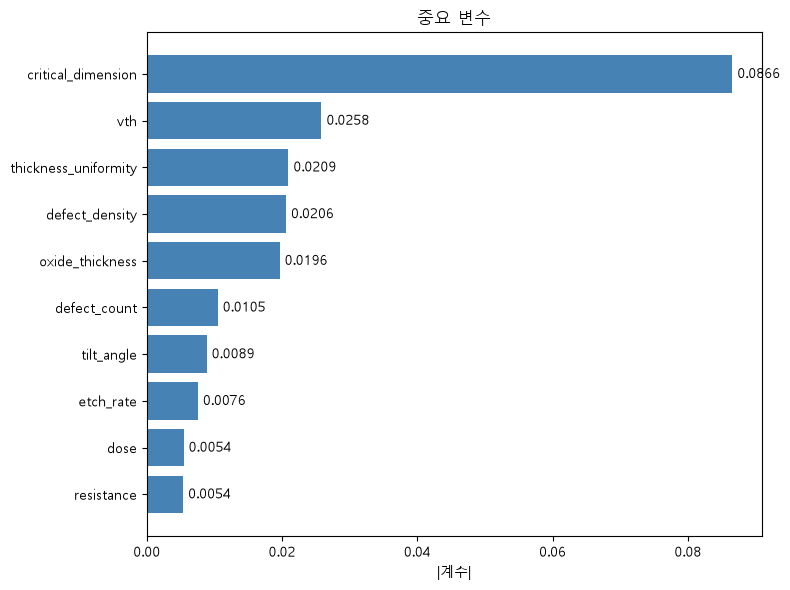

critical_dimension      0.086570
vth                     0.025821
thickness_uniformity    0.020932
defect_density          0.020583
oxide_thickness         0.019647
defect_count            0.010489
tilt_angle              0.008855
etch_rate               0.007558
dose                    0.005447
resistance              0.005376
dtype: float64

In [7]:
import os

# 한글이 깨지지 않게 폰트를 먼저 잡는다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# Step 3~5에서 이미 구한 중요도(중요도, 18개 전체)에서 상위 10개만 뽑는다
중요도_상위10 = 중요도.head(10)

fig, ax = plt.subplots(figsize=(8, 6))
# barh는 아래부터 그리므로, 순서를 뒤집어 1위가 맨 위에 오게 한다
막대 = ax.barh(중요도_상위10.index[::-1], 중요도_상위10.values[::-1], color="steelblue")
ax.set_title("중요 변수")
ax.set_xlabel("|계수|")

# 막대 옆에 값을 적는다
for 막대하나, 값 in zip(막대, 중요도_상위10.values[::-1]):
    ax.text(막대하나.get_width(), 막대하나.get_y() + 막대하나.get_height() / 2,
            f" {값:.4f}", va="center", ha="left")

plt.tight_layout()

# results 폴더를 만들고 그림을 저장한다
os.makedirs("results", exist_ok=True)
plt.savefig("results/fig1_importance.png", dpi=150, bbox_inches="tight")
plt.show()

중요도_상위10

## Step 2. 그림 2 - 어떻게 틀렸나

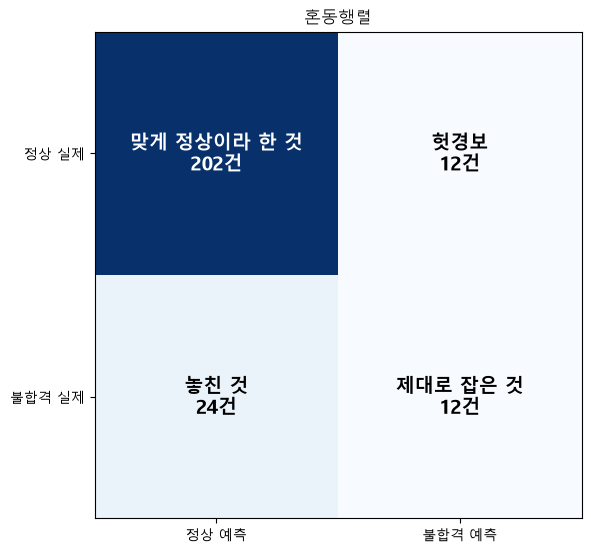

불합격 기준(하위 25%): yield < 0.3236


array([[202,  12],
       [ 24,  12]])

In [8]:
from sklearn.metrics import confusion_matrix

# yield는 연속값이라 혼동행렬을 그리려면 정상/불합격 기준선이 필요하다
# 전체 데이터 하위 25%를 불합격 기준으로 삼는다 (근거: 자연스러운 경계가 없고, 평균 기준은 절반 이상이 걸려 부적절하며,
# 하위 10%는 시험용에 11건뿐이라 표가 비어 보임 - 하위 25%가 시험용 250건 중 36건으로 가장 합리적)
문턱 = df["yield"].quantile(0.25)

실제_불합격 = (y_test < 문턱).astype(int)
예측_불합격 = (내_예측 < 문턱).astype(int)

cm = confusion_matrix(실제_불합격, 예측_불합격)

라벨 = [["맞게 정상이라 한 것", "헛경보"],
        ["놓친 것", "제대로 잡은 것"]]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cm, cmap="Blues")
ax.set_title("혼동행렬")
ax.set_xticks([0, 1])
ax.set_xticklabels(["정상 예측", "불합격 예측"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["정상 실제", "불합격 실제"])

# 칸마다 이름과 건수를 크게 적는다
for i in range(2):
    for j in range(2):
        색 = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{라벨[i][j]}\n{cm[i, j]}건", ha="center", va="center",
                fontsize=14, fontweight="bold", color=색)

plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/fig2_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"불합격 기준(하위 25%): yield < {문턱:.4f}")
cm

## Step 3. 그림 3 - 기준 모델보다 나은가

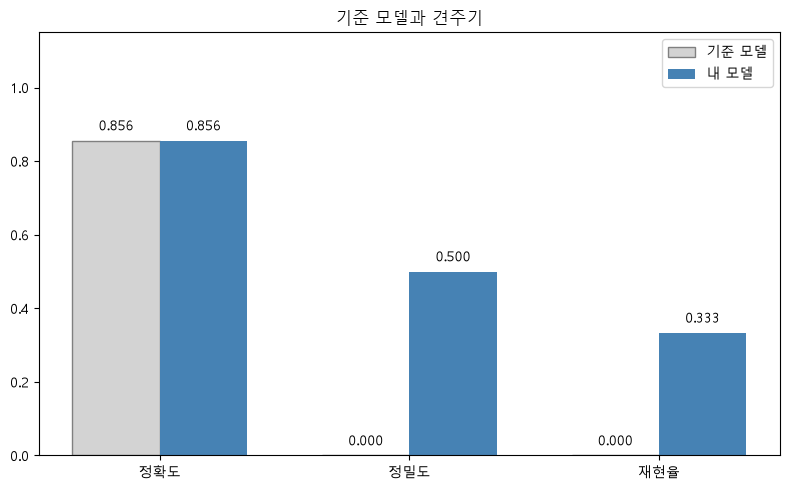

,기준 모델,내 모델
정확도,0.856,0.856000
정밀도,0.000,0.500000
재현율,0.000,0.333333


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 기준 모델(항상 학습용 평균 예측)도 같은 문턱으로 이진화한다
기준_불합격 = (기준_예측 < 문턱).astype(int)

지표_기준 = [
    accuracy_score(실제_불합격, 기준_불합격),
    precision_score(실제_불합격, 기준_불합격, zero_division=0),
    recall_score(실제_불합격, 기준_불합격, zero_division=0),
]
지표_내모델 = [
    accuracy_score(실제_불합격, 예측_불합격),
    precision_score(실제_불합격, 예측_불합격, zero_division=0),
    recall_score(실제_불합격, 예측_불합격, zero_division=0),
]

이름 = ["정확도", "정밀도", "재현율"]
x = np.arange(len(이름))
너비 = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
막대_기준 = ax.bar(x - 너비 / 2, 지표_기준, 너비, label="기준 모델", color="lightgray", edgecolor="gray")
막대_내모델 = ax.bar(x + 너비 / 2, 지표_내모델, 너비, label="내 모델", color="steelblue")

ax.set_title("기준 모델과 견주기")
ax.set_xticks(x)
ax.set_xticklabels(이름)
ax.set_ylim(0, 1.15)
ax.legend()

# 막대 위에 값을 적는다
for 막대묶음 in [막대_기준, 막대_내모델]:
    for 막대하나 in 막대묶음:
        높이 = 막대하나.get_height()
        ax.text(막대하나.get_x() + 막대하나.get_width() / 2, 높이 + 0.02, f"{높이:.3f}",
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/fig3_compare.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"기준 모델": 지표_기준, "내 모델": 지표_내모델}, index=이름)